In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from pathlib import Path
import numpy as np

from scipy.io import loadmat, whosmat

mat_path = Path('./data/theta_002_015_3000.mat')


mat_data = loadmat(mat_path, simplify_cells=True)

theta = np.array(mat_data['theta'])
theta = np.squeeze(theta)

if theta.shape[-1] == 128:
    pass
elif theta.shape[0] == 128:
    theta = theta.T

x = np.linspace(-np.pi, np.pi, num=theta.shape[-1], endpoint=False)
time_steps = np.arange(theta.shape[0])

mat_path = Path('./data/R_local_1_002_015_3000.mat')
mat_data = loadmat(mat_path, simplify_cells=True)
data_keys = [key for key in mat_data.keys() if not key.startswith('__')]
print(f"Available data keys: {data_keys}")

if 'R_local_1' in mat_data:
    R_local_1_array = np.asarray(mat_data['R_local_1'])
    R_local_1_array = np.abs(R_local_1_array)
elif data_keys:
    first_key = data_keys[0]
    R_local_1_array = np.asarray(mat_data[first_key])
    R_local_1_array = np.abs(R_local_1_array)
    print(f"Key 'R_local_1' not found; using first data key '{first_key}'.")
else:
    raise ValueError('No data arrays found in MAT file.')

print(f"R_local_1_array shape: {R_local_1_array.shape}, dtype: {R_local_1_array.dtype}")


n_rows, n_cols = R_local_1_array.shape
positions = np.linspace(-np.pi, np.pi, num=n_cols, endpoint=False)
row_max_indices = np.argmax(R_local_1_array, axis=1)
row_max_positions = positions[row_max_indices]

time_axis = np.arange(row_max_positions.shape[0])

Available data keys: ['R_local_1']
R_local_1_array shape: (300001, 128), dtype: float64


In [ ]:
r = loadmat('./data/chaos01.mat')['r'][0]
M = loadmat('./data/chaos01.mat')['M'][0]
K_median = loadmat('./data/chaos01.mat')['K_median'][0][0]
log_n = np.log(r)
log_M = np.log(M)
slope, log_a = np.polyfit(log_n, log_M, 1)
M_fit = np.exp(log_a) * r**slope

In [ ]:
fit_x = loadmat('./data/lyapunov.mat')['fit_x'][0]
fit_y = loadmat('./data/lyapunov.mat')['fit_y'][0]

fit_slope, fit_intercept = np.polyfit(fit_x, fit_y, 1)
fit_pred = fit_intercept + fit_slope * fit_x
ss_res = np.sum((fit_y - fit_pred)**2)
ss_tot = np.sum((fit_y - fit_y.mean())**2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

In [ ]:
embedded = loadmat('./data/attractor.mat')['embedded']

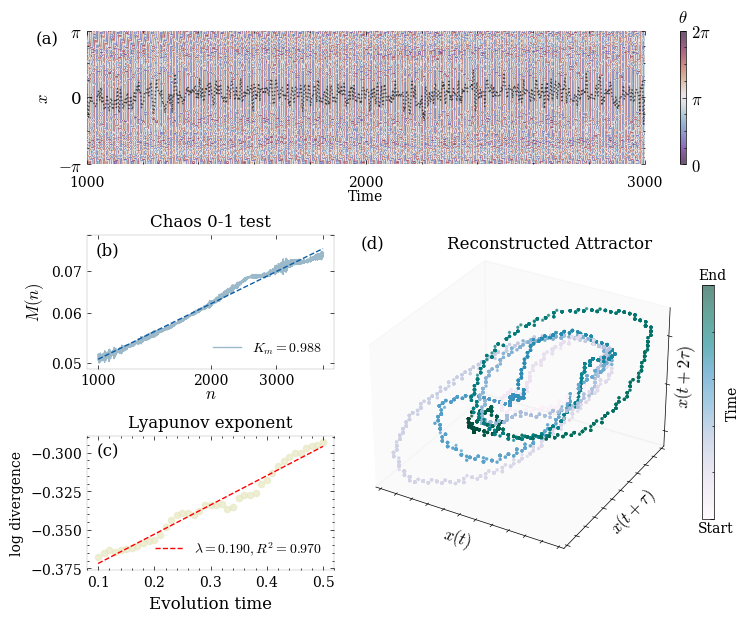

In [ ]:
length_size = np.arange(-200001,0,10)
label_position = [100000, 200000,300000]
import scienceplots
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import matplotlib.ticker as mticker
from matplotlib.ticker import LogLocator, FuncFormatter

result = theta[length_size,:]
with plt.style.context(['science', 'no-latex']):
    fig = plt.figure(figsize=(9, 7))

    gs_main = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[0.8, 2], hspace=0.3) # , height_ratios=[2, 1]

    x = np.linspace(-np.pi, np.pi, result.shape[1], endpoint=False)
    ax = fig.add_subplot(gs_main[0])
    im = ax.imshow(
    result.T,
    cmap='twilight_shifted',
    vmin=np.min(result), vmax=np.max(result),
    aspect='auto',        
    origin='lower',        
    extent=[time_axis[length_size][0], time_axis[length_size][-1], x.min(), x.max()],
    alpha=0.7
    )
    

    cbar = fig.colorbar(im, ax=ax)
    

    ax.set_xticks(ticks=np.array(label_position), labels=[ '1000', '2000', '3000'], rotation=0)
    
    ax.plot(time_axis[length_size][::20],row_max_positions[length_size][::20] ,color='#404040', linewidth=1, linestyle=':',zorder=1)

    ax.set_yticks(ticks=np.array([-np.pi,0,np.pi-0.06]), labels=[r'$-\pi$', '0', r'$\pi$'], rotation=0, fontsize=12)
    ax.set_ylabel(r"$x$", fontsize=12)

    ax.text(-0.05, 1, '(a)', transform=ax.transAxes,ha='right', va='top', fontsize=12)
    ax.set_xlabel('Time', labelpad=0)
    ax.tick_params(axis='x', pad=8)
    for spine in ax.spines.values():
        spine.set_linewidth(0.01)  


    cbar.set_ticks([0, np.pi, 2*np.pi])
    

    cbar.set_ticklabels([r'$0$',r'$\pi$', r'$2\pi$'], fontsize=12)

    cbar.ax.set_title(r"$\theta$", pad=6)


    gs_1 = gs_main[1].subgridspec(1, 2,width_ratios = [0.9,2], wspace=-0.25)
    gs_right = gs_1[0].subgridspec(2, 1, hspace=0.5)

    ax2 = fig.add_subplot(gs_right[0, 0]) 
    ax2.loglog(r, M, label=rf'$K_m={K_median:.3f}$', color='#9CB9CA')
    ax2.loglog(r, M_fit, '--') 
    ax2.set_xlabel(r'$n$', labelpad=-2, fontsize=12)
    ax2.set_ylabel(r'$M(n)$', fontsize=12)
    ax2.set_title('Chaos 0-1 test')

    ax2.legend(loc='lower right')
    ticks = [0.05, 0.06, 0.07, 0.08]
    labels = [0.05, 0.06,0.07, '']
    
    ax2.set_yticks(ticks)
    ax2.set_yticklabels(labels)
    ax2.tick_params(axis='y')
    ticks = [1000, 2000, 3000, 4000]
    labels = [1000, 2000, 3000, '']
    
    ax2.set_xticks(ticks)
    ax2.set_xticklabels(labels)
    
    
    ax2.text(0.13, 0.95, '(b)', transform=ax2.transAxes,ha='right', va='top', fontsize=12)


    for spine in ax2.spines.values():
        spine.set_linewidth(0.1) 
    
    ax3 = fig.add_subplot(gs_right[1, 0])  # 右下
    ax3.scatter(fit_x, fit_y, s=20, alpha=0.7,color='#E7E7C3')
    ax3.plot(fit_x, fit_intercept + fit_slope * fit_x, 'r--', label=rf'$\lambda = {fit_slope:.3f}, R^2={r2:.3f}$' )

    ax3.set_xlabel('Evolution time', fontsize=12)
    ax3.set_ylabel('log divergence')
    ax3.set_title('Lyapunov exponent')
    ax3.legend(loc='lower right')
    ax3.text(0.13, 0.95, '(c)', transform=ax3.transAxes,ha='right', va='top', fontsize=12)
    for spine in ax3.spines.values():
        spine.set_linewidth(0.1)  


    ax = fig.add_subplot(gs_1[1], projection='3d')
    t = np.linspace(0, 1, embedded.shape[0]) 
    sc = ax.scatter(embedded[:, 0], embedded[:, 1], embedded[:, 2], c=t, alpha=0.6, s=2,cmap="PuBuGn")
    cb = fig.colorbar(sc, ax=ax, pad=0.03, shrink=0.7)
    ticks = [0,1]
    cb.set_ticks(ticks)  
    cb.set_ticklabels(["", ""]) 

    cb.ax.text(-0.3, -0.01, "Start", transform=cb.ax.transAxes, va="top")
    cb.ax.text(-0.3,1.01 , "End",   transform=cb.ax.transAxes, va="bottom")

    cb.set_label('Time', labelpad=5)
    ax.tick_params(axis='x', pad=1, length=3)
    ax.tick_params(axis='y', pad=1, length=3)
    ax.tick_params(axis='z', pad=5, length=3)

    ax.xaxis.set_major_locator(MaxNLocator(3))
    ax.yaxis.set_major_locator(MaxNLocator(3))
    ax.zaxis.set_major_locator(MaxNLocator(3))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.set_xlabel(rf'$x(t)$', fontsize=12,labelpad=-10)
    ax.set_ylabel(rf'$x(t+\tau)$', fontsize=12,labelpad=-10)
    ax.set_zlabel(rf'$x(t+2\tau)$', fontsize=12,labelpad=-13)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    white_rgba = (0.9, 0.9, 0.9, 1.0)
    ax.xaxis.set_pane_color(white_rgba)
    ax.yaxis.set_pane_color(white_rgba)
    ax.zaxis.set_pane_color(white_rgba)
    ax.xaxis.pane.set_alpha(0.2)
    ax.yaxis.pane.set_alpha(0.2)
    ax.zaxis.pane.set_alpha(0.2)
    

    ax.xaxis._axinfo['grid']['color'] = (0.85, 0.85, 0.85, 1)
    ax.yaxis._axinfo['grid']['color'] = (0.85, 0.85, 0.85, 1)
    ax.zaxis._axinfo['grid']['color'] = (0.85, 0.85, 0.85, 1)
    ax.grid(False)
    ax.text2D(0.9, 1,f"Reconstructed Attractor", transform=ax.transAxes,ha='right', va='top', fontsize=12, rotation=0)
    ax.text2D(0.1, 1, '(d)', transform=ax.transAxes,ha='right', va='top', fontsize=12)
    for spine in ax.spines.values():
        spine.set_linewidth(0.001) 
plt.show()